In [23]:
import os
import numpy as np
from time import time
from math import floor, ceil
from PIL import Image

# from sys import platform as sys_pf
# if sys_pf == 'darwin':
#     import matplotlib
#     matplotlib.use("TkAgg")
import matplotlib.pyplot as plt

import cv2

from scipy import signal
from scipy.io import wavfile
from skimage import exposure, measure

In [ ]:
def bradley_roth_numpy(image, s=None, t=None):

    # Convert image to numpy array
    img = np.array(image).astype(np.float)

    # Default window size is round(cols/8)
    if s is None:
        s = np.round(img.shape[1]/8)

    # Default threshold is 20% of the total
    # area in the window
    if t is None:
        t = 20.0

    # Compute integral image
    intImage = np.cumsum(np.cumsum(img, axis=1), axis=0)

    # Define grid of points
    (rows,cols) = img.shape[:2]
    (X,Y)       = np.meshgrid(np.arange(cols), np.arange(rows))

    # Make into 1D grid of coordinates for easier access
    X = X.ravel()
    Y = Y.ravel()

    # Ensure s is even so that we are able to index into the image
    # properly
    s = s + np.mod(s,2)

    # Access the four corners of each neighbourhood
    x1 = X - s/2
    x2 = X + s/2
    y1 = Y - s/2
    y2 = Y + s/2

    # Ensure no coordinates are out of bounds
    x1[x1 < 0]     = 0
    x2[x2 >= cols] = cols-1
    y1[y1 < 0]     = 0
    y2[y2 >= rows] = rows-1

    # Ensures coordinates are integer
    x1 = x1.astype(np.int)
    x2 = x2.astype(np.int)
    y1 = y1.astype(np.int)
    y2 = y2.astype(np.int)

    # Count how many pixels are in each neighbourhood
    count = (x2 - x1) * (y2 - y1)

    # Compute the row and column coordinates to access
    # each corner of the neighbourhood for the integral image
    f1_x           = x2
    f1_y           = y2
    f2_x           = x2
    f2_y           = y1 - 1
    f2_y[f2_y < 0] = 0
    f3_x           = x1-1
    f3_x[f3_x < 0] = 0
    f3_y           = y2
    f4_x           = f3_x
    f4_y           = f2_y

    # Compute areas of each window
    sums = intImage[f1_y, f1_x] - intImage[f2_y, f2_x] - intImage[f3_y, f3_x] + intImage[f4_y, f4_x]

    # Compute thresholded image and reshape into a 2D grid
    out = np.ones(rows*cols, dtype=np.bool)
    out[img.ravel()*count <= sums*(100.0 - t)/100.0] = False

    # Also convert back to uint8
    out = 255*np.reshape(out, (rows, cols)).astype(np.uint8)

    # Return PIL image back to user
    return out

def imshow_components(labels):
    # Map component labels to hue val
    label_hue = np.uint8(179*labels/np.max(labels))
    blank_ch = 255*np.ones_like(label_hue)
    labeled_img = cv2.merge([label_hue, blank_ch, blank_ch])

    # cvt to BGR for display
    labeled_img = cv2.cvtColor(labeled_img, cv2.COLOR_HSV2BGR)

    # set bg label to black
    labeled_img[label_hue==0] = 0

    plt.imshow(labeled_img)
    plt.show()

In [4]:
file_path = '/Users/gustavo/Documents/git/ahof_vocalmat/audios/audio_example.wav'
print("selected file: {}".format(file_path))

timeA = time()
sample_rate, samples = wavfile.read(file_path)
samples = samples / np.iinfo(np.int16).max
timeB = time()
print("load audio runtime: {}".format(timeB - timeA))

fs       = sample_rate
window   = signal.get_window('hamming', 256)
nperseg  = 256
noverlap = None
nfft     = 1024

timeA = time()
f, t, Sxx = signal.spectrogram(samples[ceil(0.3*sample_rate):60*sample_rate], fs=fs, 
                                                          window=window, 
                                                          nperseg=nperseg, 
                                                          noverlap=noverlap, 
                                                          nfft=nfft, 
                                                          detrend='constant', 
                                                          return_onesided=True, 
                                                          scaling='density', 
                                                          axis=-1, 
                                                          mode='psd')

timeB = time()
print("spectrogram runtime: {}".format(timeB - timeA))

Pxx = 10*np.log10(Sxx)
# Pxx = np.flipud(Pxx)
Pxx = Pxx[(f>45000)]
f = f[(f>45000)]

selected file: /Users/gustavo/Documents/git/ahof_vocalmat/audios/audio_example.wav


/Users/gustavo/anaconda3/lib/python3.7/site-packages/scipy/io/wavfile.py:273: WavFileWarning: Chunk (non-data) not understood, skipping it.
  WavFileWarning)


load audio runtime: 1.666886806488037
spectrogram runtime: 1.5171787738800049


In [5]:
np.unique(Pxx[:,20200:20700])
B = np.abs(Pxx)/np.max(np.abs(Pxx))
B = exposure.rescale_intensity(B, in_range='image', out_range=(np.uint8))
np.unique(B[:,20200:20700])

array([  3.63428397,   3.70047003,   4.53593578, ..., 143.46617852,
       153.01874498, 188.05204327])

In [6]:
file_path = '/Users/gustavo/Documents/git/ahof_vocalmat/audios/audio_example.wav'
print("selected file: {}".format(file_path))

timeA = time()
sample_rate, samples = wavfile.read(file_path)
#samples = samples / np.iinfo(np.int16).max
timeB = time()
print("load audio runtime: {}".format(timeB - timeA))

fs       = sample_rate
window   = signal.get_window('hamming', 256)
nperseg  = 256
noverlap = None
nfft     = 1024

timeA = time()
f, t, Sxx = signal.spectrogram(samples[ceil(0.3*sample_rate):60*sample_rate], fs=fs, 
                                                          window=window, 
                                                          nperseg=nperseg, 
                                                          noverlap=noverlap, 
                                                          nfft=nfft, 
                                                          detrend='constant', 
                                                          return_onesided=True, 
                                                          scaling='density', 
                                                          axis=-1, 
                                                          mode='psd')

timeB = time()
print("spectrogram runtime: {}".format(timeB - timeA))

Pxx = 10*np.log10(Sxx)
# Pxx = np.flipud(Pxx)
Pxx = Pxx[(f>45000)]
f = f[(f>45000)]

selected file: /Users/gustavo/Documents/git/ahof_vocalmat/audios/audio_example.wav
load audio runtime: 0.24157404899597168
spectrogram runtime: 1.7854893207550049


In [7]:
np.unique(Pxx[:,20200:20700])
B = np.abs(Pxx)/np.max(np.abs(Pxx))
B = exposure.rescale_intensity(B, in_range='image', out_range=(np.uint8))
np.unique(B[:,20200:20700])

array([2.2024156e-05, 5.9954884e-05, 8.6872795e-05, ..., 1.0858292e+02,
       1.2112900e+02, 1.6714272e+02], dtype=float32)

In [8]:
B = Pxx
#-- normalize data
B = np.abs(B)/np.max(np.abs(B))
# plt.pcolormesh(t, f, B, cmap='gray')
# plt.show()

#-- rescale intensity values to be between (0,1)
# B = exposure.rescale_intensity(B, in_range='image', out_range=(0,1))
B = exposure.rescale_intensity(B, in_range='image', out_range=(np.uint8))
# plt.pcolormesh(t, f, B, cmap='gray')
# plt.show()

#-- image complement
B = 255 - B
# plt.pcolormesh(t, f, B, cmap='gray')
# plt.show()


#-- contrast adjustment
B = exposure.adjust_gamma(B,2)
# plt.pcolormesh(t, f, B, cmap='gray')
# plt.show()

#-- treshold spectrogram
BB = bradley_roth_numpy(B, t=10)
BB = 255 - BB

In [9]:
kernel_rect  = np.ones((4,2), np.uint8)
kernel_line1 = np.ones((4,1), np.uint8)
kernel_line2 = np.ones((5,1), np.uint8)

# -- morphological operations
erode11  = cv2.erode(BB, kernel_rect, iterations=1)
dilate12 = cv2.dilate(erode11, kernel_rect, iterations=1)
dilate13 = cv2.dilate(dilate12, kernel_line2, iterations=1)
erode14  = cv2.erode(dilate13, kernel_line1, iterations=2)

In [10]:
t.shape

(66629,)

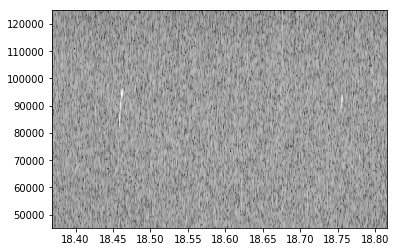

In [11]:
fig = plt.figure()
plt.pcolormesh(t[20500:21000], f, Pxx[:,20500:21000], cmap='gray')

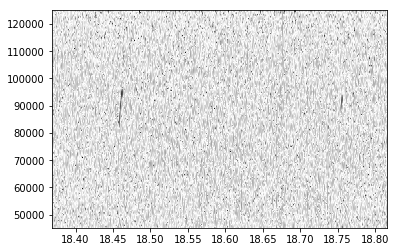

In [12]:
fig = plt.figure()
plt.pcolormesh(t[20500:21000], f, B[:,20500:21000], cmap='gray')

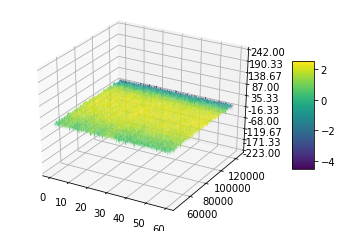

In [41]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
# %matplotlib qt 
fig = plt.figure()
ax = fig.gca(projection='3d')
X, Y = np.meshgrid(t[420:-375], f)
surf = ax.plot_surface(X, Y, Pxx[:,420:-375], cmap=cm.viridis, linewidth=0, antialiased=True)

ax.set_zlim(-223, 242)
ax.zaxis.set_major_locator(LinearLocator(10))
ax.zaxis.set_major_formatter(FormatStrFormatter('%.02f'))

# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=5)

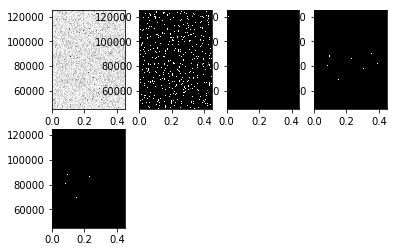

In [42]:
fig = plt.figure()
ax  = fig.add_subplot(241)
ax.pcolormesh(t[0:500], f, B[:,0:500], cmap='gray')
ax  = fig.add_subplot(242)
ax.pcolormesh(t[0:500], f, BB[:,0:500], cmap='gray')
ax  = fig.add_subplot(243)
plt.pcolormesh(t[0:500], f, erode11[:,0:500], cmap='gray')
ax  = fig.add_subplot(244)
plt.pcolormesh(t[0:500], f, dilate12[:,0:500], cmap='gray')
ax  = fig.add_subplot(245)
#plt.pcolormesh(t[0:500], f, dilate13[:,0:500], cmap='gray')
plt.pcolormesh(t[0:500], f, erode14[:,0:500], cmap='gray')

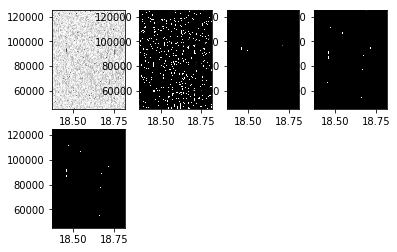

In [43]:
fig = plt.figure()
ax  = fig.add_subplot(241)
ax.pcolormesh(t[20500:21000], f, B[:,20500:21000], cmap='gray')
ax  = fig.add_subplot(242)
ax.pcolormesh(t[20500:21000], f, BB[:,20500:21000], cmap='gray')
ax  = fig.add_subplot(243)
plt.pcolormesh(t[20500:21000], f, erode11[:,20500:21000], cmap='gray')
ax  = fig.add_subplot(244)
plt.pcolormesh(t[20500:21000], f, dilate12[:,20500:21000], cmap='gray')
ax  = fig.add_subplot(245)
#plt.pcolormesh(t[20500:21000], f, dilate13[:,20500:21000], cmap='gray')
plt.pcolormesh(t[20500:21000], f, erode14[:,20500:21000], cmap='gray')

In [12]:
connectivity = 4
num_cc, output, stats, centroids = cv2.connectedComponentsWithStats(erode14, connectivity, cv2.CV_32S)
#-- remove background stats
num_cc = num_cc - 1
areas  = stats[1:,4]

In [13]:
nr     = np.arange(num_cc)
ranked = sorted(zip(areas,nr))

In [14]:
#your answer image
img2 = np.zeros((output.shape))
#for every component in the image, you keep it only if it's above min_area
min_area = 60
for i in range(0, num_cc):
    if areas[i] >= min_area:
        img2[output == i + 1] = 255

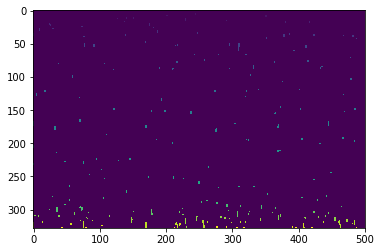

In [15]:
plt.imshow(output[:,0:500])

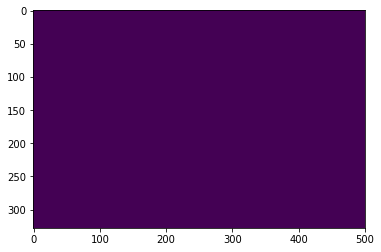

In [16]:
grain = img2.astype(np.uint8)
plt.imshow(grain[:,0:500])

In [17]:
#-- kernels for morphological operations
kernel_line = np.ones((1,3), np.uint8)

#-- morphological operation
opening12   = cv2.dilate(grain, kernel_line, iterations=1)

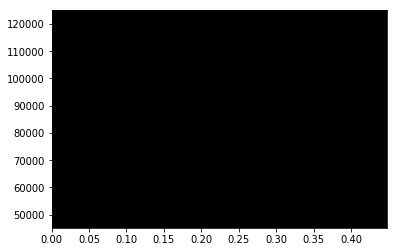

In [18]:
fig = plt.figure()
plt.pcolormesh(t[0:500], f, opening12[:,0:500], cmap=cm.gray)

In [19]:
grain_bool = (grain > 0) * 1
bw = B * grain_bool

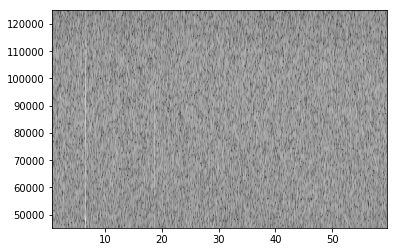

In [20]:
plt.pcolormesh(t[700:-100], f, B[:,700:-100], cmap='gray')

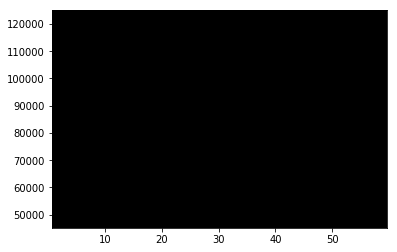

In [21]:
plt.pcolormesh(t[700:-100], f, bw[:,700:-100], cmap='gray')

In [ ]:

y0, x0 = props.centroid
orientation = props.orientation
x1 = x0 + math.cos(orientation) * 0.5 * props.major_axis_length
y1 = y0 - math.sin(orientation) * 0.5 * props.major_axis_length
x2 = x0 - math.sin(orientation) * 0.5 * props.minor_axis_length
y2 = y0 - math.cos(orientation) * 0.5 * props.minor_axis_length

ax.plot((x0, x1), (y0, y1), '-r', linewidth=2.5)
ax.plot((x0, x2), (y0, y2), '-r', linewidth=2.5)
ax.plot(x0, y0, '.g', markersize=15)

minr, minc, maxr, maxc = props.bbox
bx = (minc, maxc, maxc, minc, minc)
by = (minr, minr, maxr, maxr, minr)
ax.plot(bx, by, '-b', linewidth=2.5)

In [24]:
from vocal import Vocal
from list_of_vocals import ListOfVocals
from recording import Recording

In [121]:
recording = np.load('/Users/gustavo/Documents/git/vocalpy/audios/1304_Agrp-Trpv1_1st_outputs/recording.vocalpy', allow_pickle=True)
list_of_vocals = recording._list_of_vocals

Vocal:
 bin_number: 2 
 start: 60.015360196610516 
 end: 60.05120065536839 
 duration: 35.8404587578721 
 interval: 3983.706021804778 
 min_freq: 76219.51219512195 
 max_freq: 96219.51219512196 
 avg_freq: 85099.60413740264 
 bandwidth: 20000.000000000015 
 min_intensity: -138.5650328483693 
 max_intensity: -81.63937485084284 
 avg_intensity: -105.88309783568397 
 bg_intensity: -120.81804910385696 
 area: 1337 
 centroid: [164, 200] 
 orientation: None 



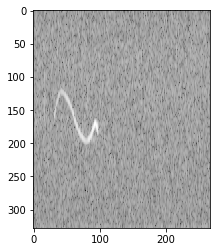

In [122]:
idx = 112
print(list_of_vocals.vocals_in_recording[idx])
plt.imshow(list_of_vocals.vocals_in_recording[idx].spectrogram, cmap='gray')

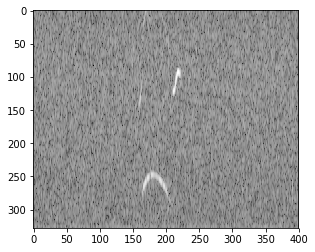

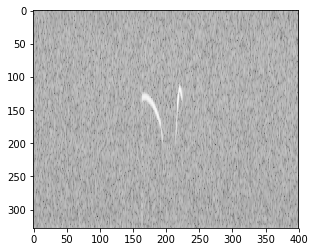

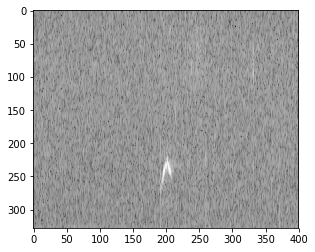

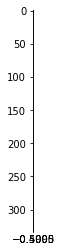

In [94]:
for i in range(109,113):
    plt.figure()
    plt.imshow(list_of_vocals.vocals_in_recording[i].spectrogram, cmap='gray')

In [76]:
list(list_of_vocals.vocals_in_recording).sort(key=lambda x: x.start, reverse=True)

Vocal:
 bin_number: 10 
 start: 599.7076442578465 
 end: 599.7296605396549 
 duration: 0.02201628180841908 
 interval: 17.408222825224584 
 min_freq: 49390.243902439026 
 max_freq: 104268.29268292684 
 avg_freq: 86734.01133738333 
 bandwidth: 54878.048780487814 
 min_intensity: -109.18720061622653 
 max_intensity: -65.03754909886793 
 avg_intensity: -74.77048484795688 
 bg_intensity: -87.2413468968571 
 area: 488 
 centroid: [200, 171.5] 
 orientation: None 

Vocal:
 bin_number: 10 
 start: 599.7465567559265 
 end: 599.7639649787517 
 duration: 17.408222825252164 
 interval: 16.89621627156157 
 min_freq: 70609.75609756098 
 max_freq: 92317.07317073172 
 avg_freq: 83679.58942119253 
 bandwidth: 21707.317073170736 
 min_intensity: -111.3260907326159 
 max_intensity: -40.35266590033271 
 avg_intensity: -70.42660630960675 
 bg_intensity: -87.2040873316953 
 area: 1257 
 centroid: [200, 159] 
 orientation: None 



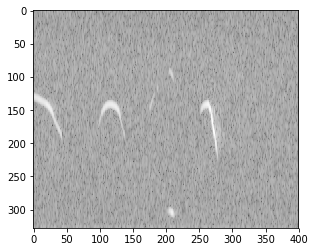

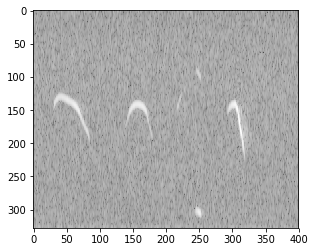

In [86]:
print(list_of_vocals.vocals_in_recording[1162])
print(list_of_vocals.vocals_in_recording[1163])
plt.imshow(list_of_vocals.vocals_in_recording[1162].spectrogram, cmap='gray')
plt.figure()
plt.imshow(list_of_vocals.vocals_in_recording[1163].spectrogram, cmap='gray')

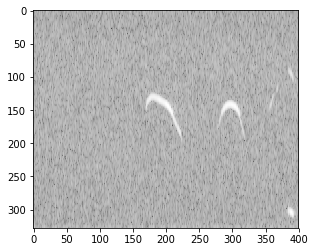

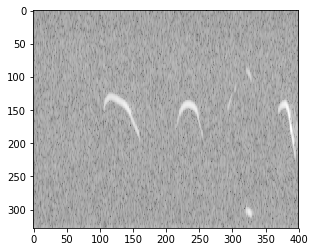

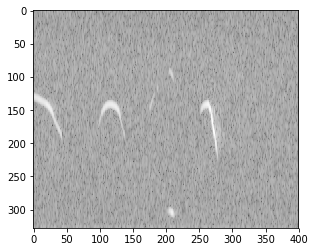

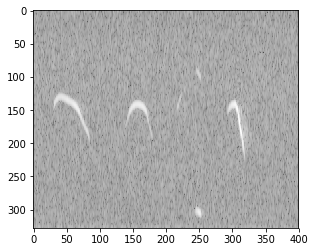

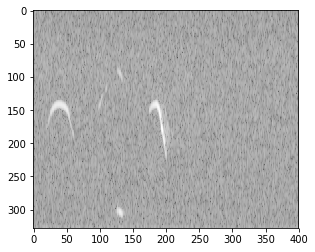

In [83]:
for i in range(1160,1165):
    plt.figure()
    plt.imshow(list_of_vocals.vocals_in_recording[i].spectrogram, cmap='gray')

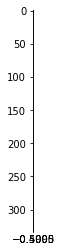

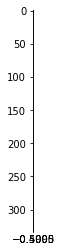

In [47]:
idx = 1168
vcl = list_of_vocals.vocals_in_recording[idx].spectrogram
plt.figure()
plt.imshow(vcl, cmap='gray')
plt.figure()
plt.imshow(list_of_vocals.vocals_in_recording[idx].mask, cmap='gray')

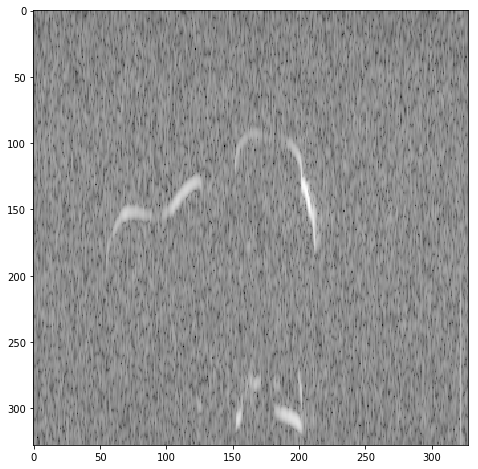

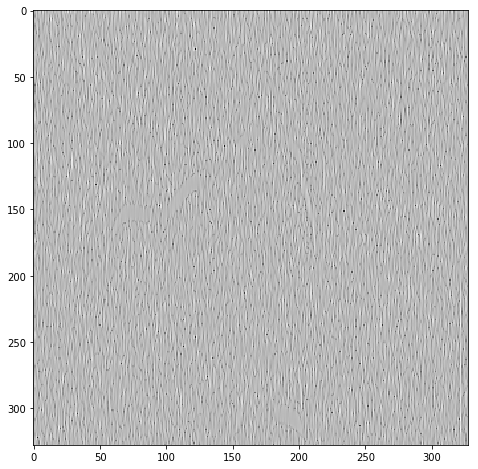

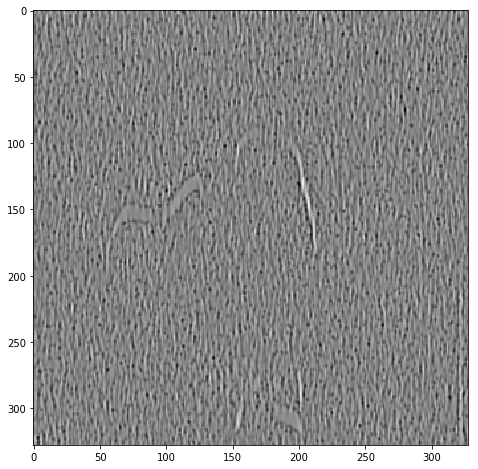

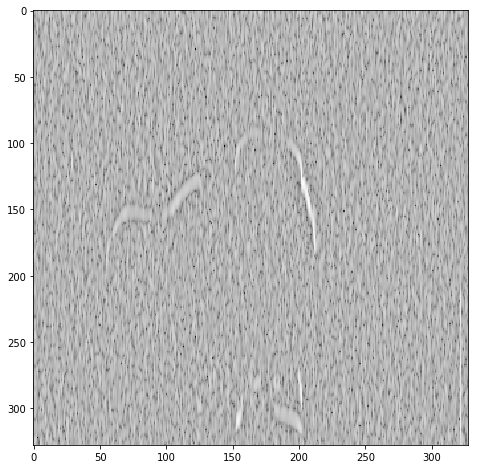

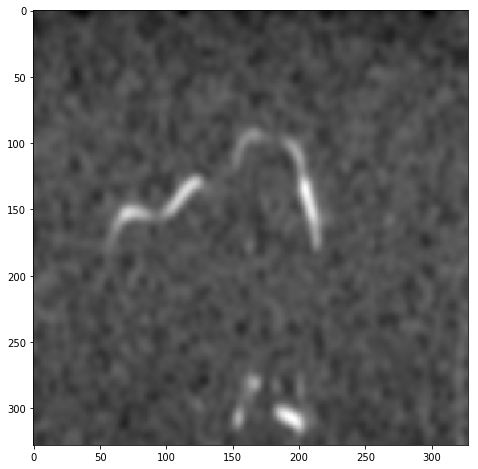

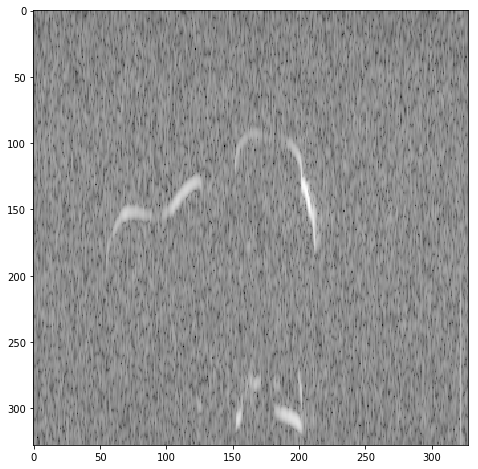

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage
from PIL import Image

# Load the data...
im = vcl
data = np.array(im, dtype=float)

plt.figure(figsize=(8,8))
plt.imshow(data ,cmap='gray')

# A very simple and very narrow highpass filter
kernel = np.array([[-1, -1, -1],
                   [-1,  8, -1],
                   [-1, -1, -1]])
highpass_3x3 = ndimage.convolve(data, kernel)

plt.figure(figsize=(8,8))
plt.imshow(highpass_3x3, cmap='gray')

# A slightly "wider", but sill very simple highpass filter 
kernel = np.array([[-1, -1, -1, -1, -1],
                   [-1,  1,  2,  1, -1],
                   [-1,  2,  4,  2, -1],
                   [-1,  1,  2,  1, -1],
                   [-1, -1, -1, -1, -1]])
highpass_5x5 = ndimage.convolve(data, kernel)

plt.figure(figsize=(8,8))
plt.imshow(highpass_5x5, cmap='gray')

# Another way of making a highpass filter is to simply subtract a lowpass
# filtered image from the original. Here, we'll use a simple gaussian filter
# to "blur" (i.e. a lowpass filter) the original.
lowpass = ndimage.gaussian_filter(data, 3)
gauss_highpass = data - lowpass

plt.figure(figsize=(8,8))
plt.imshow(gauss_highpass, cmap='gray')

plt.figure(figsize=(8,8))
plt.imshow(lowpass, cmap='gray')

plt.figure(figsize=(8,8))
plt.imshow(lowpass + gauss_highpass, cmap='gray')